In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# From wide to narrow

Read the data in wide format from a CSV file.

In [3]:
wide_data = pd.read_csv('data/weather.csv')

In [4]:
wide_data

,date,temperature,humidity
0,2026-01-01,3,76
1,2026-01-02,5,81
2,2026-01-03,4,78
3,2026-01-04,7,65
4,2026-01-05,8,60
5,2026-01-06,6,68
6,2026-01-07,4,55


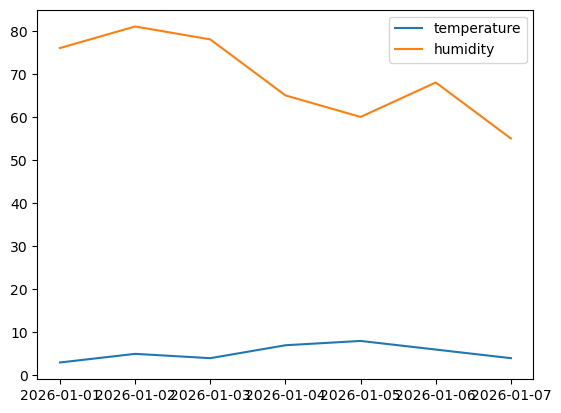

In [5]:
for condition in wide_data.columns[1:]:
    plt.plot(wide_data.date, wide_data[condition], label=condition)
plt.legend();

Converting the wide data to narrow data is straightforward using the `melt` method.  This will create a dataframe with three columns:
* the date,
* the condition, i.e., either `'temperature'` or `'humidity'`, and
* the value of the measurement.

In [6]:
narrow_data = wide_data.melt(
    id_vars='date',
    var_name='condition',
    value_name='measurement',
)

In [7]:
narrow_data

,date,condition,measurement
0,2026-01-01,temperature,3
1,2026-01-02,temperature,5
2,2026-01-03,temperature,4
3,2026-01-04,temperature,7
4,2026-01-05,temperature,8
5,2026-01-06,temperature,6
6,2026-01-07,temperature,4
7,2026-01-01,humidity,76
8,2026-01-02,humidity,81
9,2026-01-03,humidity,78


Plotting long data with matplotlib is rather difficult, but seaborn handles it gracefully.

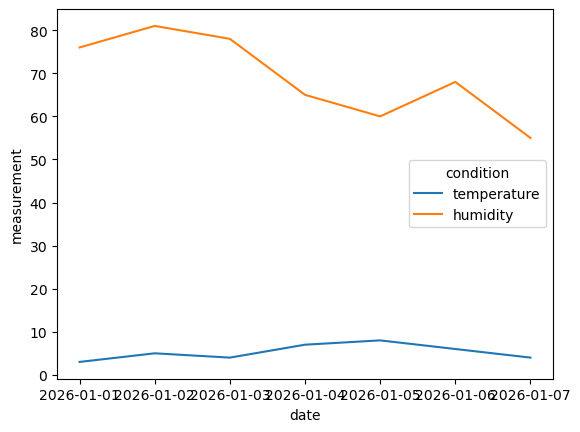

In [8]:
sns.lineplot(data=narrow_data, x='date', y='measurement', hue='condition');

# And back again

Conversion from narrow data to wide data can be done using the `pivot` method.

In [9]:
wide_data = narrow_data.pivot(
    index='date',
    columns='condition',
    values='measurement',
)

In [10]:
wide_data

condition,humidity,temperature
date,,
2026-01-01,76,3
2026-01-02,81,5
2026-01-03,78,4
2026-01-04,65,7
2026-01-05,60,8
2026-01-06,68,6
2026-01-07,55,4


In [11]:
wide_data

condition,humidity,temperature
date,,
2026-01-01,76,3
2026-01-02,81,5
2026-01-03,78,4
2026-01-04,65,7
2026-01-05,60,8
2026-01-06,68,6
2026-01-07,55,4


The `date` is an index, as intended, but it is not a column of the dataframe.  If you prefer that, apply the `reset_index` method.  Note that the index is now by row number, not date.

In [12]:
wide_data = wide_data.reset_index()

In [13]:
wide_data

condition,date,humidity,temperature
0,2026-01-01,76,3
1,2026-01-02,81,5
2,2026-01-03,78,4
3,2026-01-04,65,7
4,2026-01-05,60,8
5,2026-01-06,68,6
6,2026-01-07,55,4


As you can see, the columns are stored in an `Index` object named `condition`.

In [14]:
wide_data.columns

Index(['date', 'humidity', 'temperature'], dtype='object', name='condition')

Although that doesn't matter at all, you can reset the name using the `rename_axis` method.

In [15]:
wide_data = wide_data.rename_axis(columns=None)

In [16]:
wide_data

,date,humidity,temperature
0,2026-01-01,76,3
1,2026-01-02,81,5
2,2026-01-03,78,4
3,2026-01-04,65,7
4,2026-01-05,60,8
5,2026-01-06,68,6
6,2026-01-07,55,4


This brings you full circle to the original dataframe.

# When to use wide/narrow

Wide data works well
* for humans;
* with speadsheets;
* for simple pandas plots;
* when you own the data format.

Narrow data works well
* for plots using seaborn/plotly et al.;
* when you allow the data format to be extended.